In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys, os, time, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../model'))
sys.path.insert(0, os.path.abspath('../parameter_scan'))

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
from cariaco_obs import DEFAULT_CSV_PATH

SARDINE_CSV = "../DATA/processed/sardine_sau.csv"

# --- figure scaling (one-column; tweak to taste) -------------------------
FIG_W, FIG_H = 3.54, 5.0                                  # ≈ 90 mm single column
MARGINS = dict(left=0.15, right=0.97, top=0.95, bottom=0.08, hspace=0.10)

WINDOW = (pd.Timestamp('1996-01-01'), pd.Timestamp('2017-12-31'))
ERA_X  = [pd.Timestamp('2005-01-01'), pd.Timestamp('2014-01-01')]
ERA_LBL = [('pre', pd.Timestamp('2000-07-01')),
           ('post', pd.Timestamp('2009-07-01')),
           ('recovery', pd.Timestamp('2015-07-01'))]
C_ISO, C_MCS, C_ZOO, C_FISH = '#26456E', '#3A3A3A', '#E08214', '#1A1A1A'
UM_TICKS = [1, 2, 5, 10, 20, 40]

ERA_LBL = [('pre',      pd.Timestamp('2000-07-01'), '#2E86AB'),
           ('post',     pd.Timestamp('2009-07-01'), '#E07A5F'),
           ('recovery', pd.Timestamp('2015-07-01'), '#81B29A')]

def load_obs():     return pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
def load_sardine():
    f = pd.read_csv(SARDINE_CSV)
    f = f[(f.year >= WINDOW[0].year) & (f.year <= WINDOW[1].year)].copy()
    f['t'] = pd.to_datetime(f.year.astype(str) + '-07-01'); f['kt'] = f.sardinelandings / 1e3
    return f.sort_values('t')

def add_eras(ax, label=False):
    for x in ERA_X:
        ax.axvline(x, color='0.6', lw=0.8, zorder=1)
    if label:
        for txt, t, c in ERA_LBL:
            ax.text(t, 0.93, txt, transform=ax.get_xaxis_transform(),
                    ha='center', va='top', fontsize=8, color=c, fontweight='bold', zorder=6,
                    path_effects=[pe.withStroke(linewidth=2, foreground='white')])

In [3]:
# === Obs coverage / structure check (paste output back) ===
obs = load_obs().copy()
obs['date'] = pd.to_datetime(obs['date'])
obs['yr'] = obs['date'].dt.year
obs['mo'] = obs['date'].dt.month

def era(y):  # documented cutoffs: pre <2005, post 2005-2013, recovery >=2014
    return 'pre' if y < 2005 else ('post' if y <= 2013 else 'recovery')
obs['era'] = obs['yr'].map(era)

print("=== schema ===")
print("shape:", obs.shape)
print("date range:", obs['date'].min().date(), "->", obs['date'].max().date())
print("columns:", obs.columns.tolist())

def pick(cands):
    for c in cands:
        if c in obs.columns: return c
    return None
col_size   = pick(['size_centroid'])
col_regime = pick(['regime_adjusted','regime','upwelling'])
col_fn     = pick(['F_N','FN','Inflow__FN','f_n','FN_mmolN'])
col_de     = pick(['de','d_e','depth_cutoff','euZ','EuZ'])
col_t50    = pick(['temp_50m'])
col_tC     = pick(['Temp_C'])
col_pico   = pick(['pico_frac','frac_pico','pico','f_pico'])
col_nano   = pick(['nano_frac','frac_nano','nano','f_nano'])
col_micro  = pick(['micro_frac','frac_micro','micro','f_micro'])
col_z200   = pick(['zoo_gt200_mmolN','zoo_gt200'])
print("resolved:", dict(size=col_size, regime=col_regime, F_N=col_fn, de=col_de,
                        temp50=col_t50, TempC=col_tC, pico=col_pico, nano=col_nano,
                        micro=col_micro, z200=col_z200))

sized = obs[obs[col_size].notna()].copy() if col_size else obs.copy()
print("\nn total months:", len(obs), "| n size-complete months:", len(sized))

print("\n=== calendar coverage: distinct months sampled per year (size-complete) ===")
cov = sized.groupby('yr')['mo'].nunique().rename('n_months').to_frame()
cov['era'] = cov.index.map(era)
cov['months'] = sized.groupby('yr')['mo'].apply(lambda s: sorted(s.unique()))
print(cov.to_string())
print("\ncomplete (12-mo) years:", cov.index[cov['n_months'] == 12].tolist())
print("near-complete (>=10):  ", cov.index[cov['n_months'] >= 10].tolist())
print("decent (>=8):          ", cov.index[cov['n_months'] >= 8].tolist())

print("\n=== seasonal sampling: size-complete obs per calendar month x era ===")
cal = sized.pivot_table(index='mo', columns='era', values=col_size,
                        aggfunc='count', fill_value=0)
print(cal.to_string())

print("\n=== era x regime month counts ===")
if col_regime:
    print(sized.groupby(['era', sized[col_regime]]).size().unstack(fill_value=0).to_string())
else:
    print(sized.groupby('era').size().to_string())

if col_fn:
    print("\n=== F_N levels per era (defines the bottom-up axis of the 2x2) ===")
    print(sized.groupby('era')[col_fn].agg(['count','mean','median','min','max']).to_string())
    if col_regime:
        print("\n=== F_N per era x regime ===")
        print(sized.groupby(['era', sized[col_regime]])[col_fn]
                   .agg(['count','median','mean','min','max']).to_string())

=== schema ===
shape: (255, 52)
date range: 1995-11-01 -> 2017-01-01
columns: ['date', 'time_month', 'year', 'month', 'upwelling', 'ui', 'Isotherm_21', 'sst', 'temp_50m', 'euphotic_depth_obs', 'MLD', 'boundary_adj', 'boundary_flag', 'regime_adjusted', 'depth_cutoff', 'cutoff_source', 'TotChlA_mmolN', 'micro_mmolN', 'nano_mmolN', 'pico_mmolN', 'micro_frac', 'nano_frac', 'pico_frac', 'micro_frac_N', 'nano_frac_N', 'pico_frac_N', 'size_centroid', 'size_shannon', 'slope_2pt', 'nbss_slope', 'n_hplc_samples', 'NO3_mmolN', 'PON_mmolN', 'PP_mgC_m2_d', 'PP_mmolN_m3_d', 'Chl_niskin_mgm3', 'Phaeo_niskin_mgm3', 'Chl_niskin_mmolN', 'PhaeoChl_ratio', 'Temp_C', 'n_niskin_samples', 'FN_mmolN_m2_d', 'zoo_gt200_mmolN', 'zoo_gt500_mmolN', 'n_zoo_samples', 'export_flux_mmolN', 'export_flux_C', 'trap_CN', 'export_flux_corrected_mmolN', 'yr', 'mo', 'era']
resolved: {'size': 'size_centroid', 'regime': 'regime_adjusted', 'F_N': None, 'de': 'depth_cutoff', 'temp50': 'temp_50m', 'TempC': 'Temp_C', 'pico': 'pico

=== FORCING CLIMATOLOGIES (monthly, Jan->Dec) ===

--- pre  (F_N-complete months=88) ---
     F_N  n  de_obs  de_fromFN  T_obs  T_fromFN
mo                                             
1   4.88  7    29.3       36.5  24.16     23.62
2   5.70  7    29.3       33.3  22.91     23.28
3   6.09  7    29.2       31.7  22.27     23.12
4   2.77  8    38.1       44.9  23.48     24.49
5   5.47  7    37.2       34.2  23.47     23.37
6   2.02  8    48.3       47.9  24.12     24.80
7   2.53  9    39.9       45.8  23.30     24.59
8   1.89  7    51.8       48.4  24.50     24.86
9   1.27  5    49.4       50.8  25.85     25.11
10  1.54  7    53.6       49.8  25.84     25.00
11  1.36  9    53.1       50.5  26.05     25.08
12  2.24  7    45.0       47.0  25.43     24.71
  annual: F_N=3.15 | de obs=42.0/fromFN=43.4 | T obs=24.28/fromFN=24.34

--- post  (F_N-complete months=80) ---
     F_N  n  de_obs  de_fromFN  T_obs  T_fromFN
mo                                             
1   3.14  5    36.3       43.5 

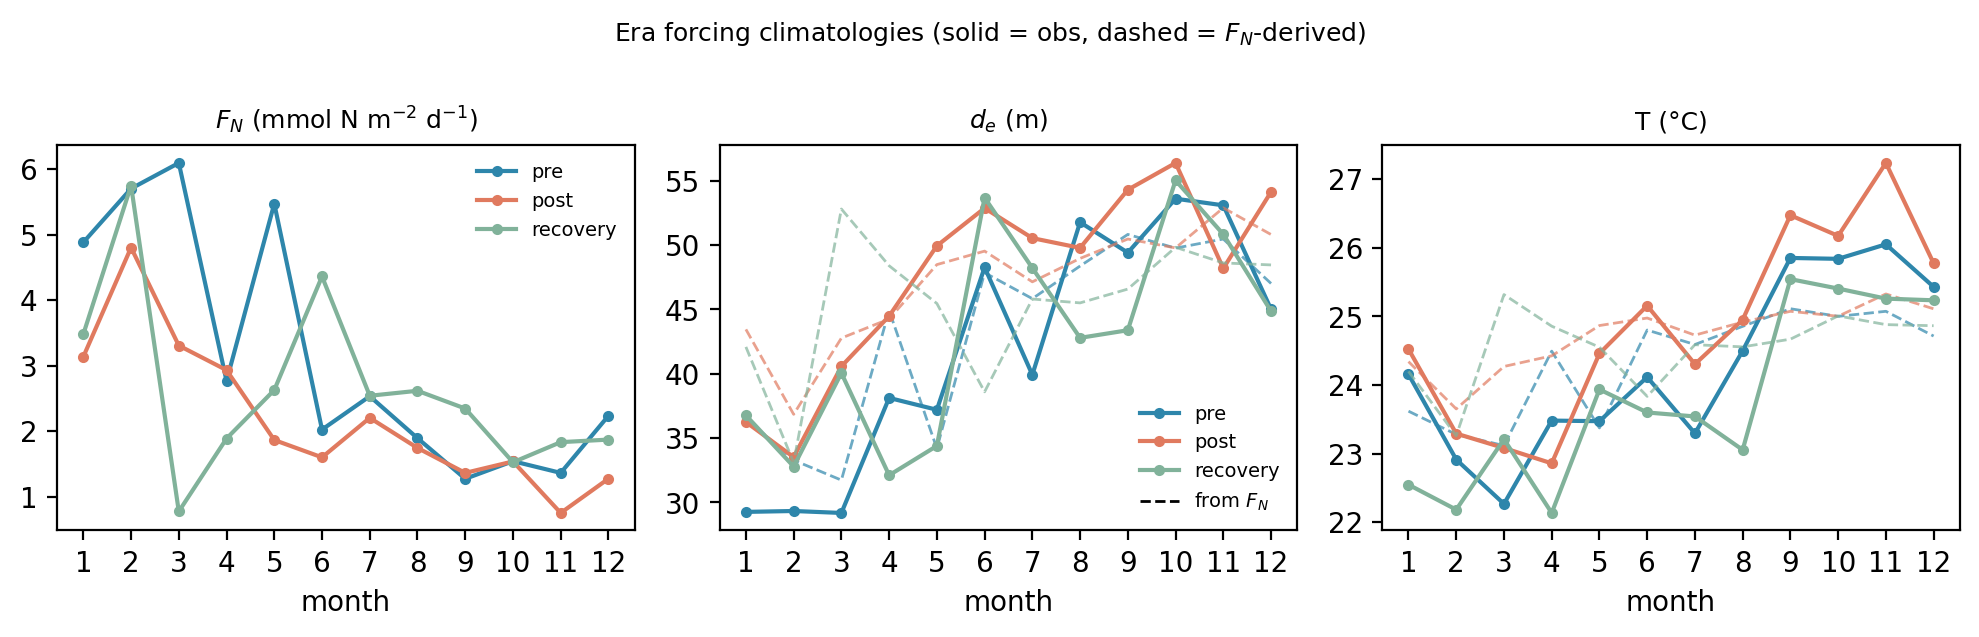

In [4]:
%config InlineBackend.figure_format = 'retina'
# === Era FORCING climatologies: F_N, d_e, T  (+ check vs F_N-derived d_e/T) ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from cariaco_obs import DEFAULT_CSV_PATH

FN, DE, TC = 'FN_mmolN_m2_d', 'depth_cutoff', 'Temp_C'
ERA_COL = {'pre':'#2E86AB','post':'#E07A5F','recovery':'#81B29A'}
GROUPS  = {'pre':['pre'], 'post':['post'], 'recovery':['recovery'],
           'pre+recovery':['pre','recovery'], 'post+recovery':['post','recovery']}

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = np.where(df['date'].dt.year < 2005, 'pre',
            np.where(df['date'].dt.year < 2014, 'post', 'recovery'))
df['mo'] = df['date'].dt.month

# handover regressions (d_e, T derived from F_N)
derive_de = lambda fn: np.clip(55.89 - 3.966*fn, 19, 69)
derive_T  = lambda fn: np.clip(25.64 - 0.414*fn, 22, 29)

def clim(d, col):
    g = d.dropna(subset=[col]).groupby('mo')[col]
    return pd.DataFrame({'mean':g.mean(),'median':g.median(),'n':g.size()}).reindex(range(1,13))

print('=== FORCING CLIMATOLOGIES (monthly, Jan->Dec) ===')
for gname, eras in GROUPS.items():
    d = df[df['era'].isin(eras)]
    cF, cD, cT = clim(d,FN), clim(d,DE), clim(d,TC)
    print(f'\n--- {gname}  (F_N-complete months={int(cF["n"].sum())}) ---')
    print(pd.DataFrame({
        'F_N':cF['mean'].round(2), 'n':cF['n'].astype('Int64'),
        'de_obs':cD['mean'].round(1), 'de_fromFN':derive_de(cF['mean']).round(1),
        'T_obs':cT['mean'].round(2),  'T_fromFN':derive_T(cF['mean']).round(2),
    }).to_string())
    print(f"  annual: F_N={cF['mean'].mean():.2f} | "
          f"de obs={cD['mean'].mean():.1f}/fromFN={derive_de(cF['mean']).mean():.1f} | "
          f"T obs={cT['mean'].mean():.2f}/fromFN={derive_T(cF['mean']).mean():.2f}")

# --- plot forcing cycles (solid=obs, dashed=derived from F_N) ---
fig, axes = plt.subplots(1, 3, figsize=(10, 3.2)); mons = list(range(1,13))
for ax, col, lab in zip(axes, [FN,DE,TC],
                        ['$F_N$ (mmol N m$^{-2}$ d$^{-1}$)','$d_e$ (m)','T (°C)']):
    for g in ['pre','post','recovery']:
        sub = df[df['era'].isin(GROUPS[g])]
        ax.plot(mons, clim(sub,col)['mean'], '-o', ms=3, color=ERA_COL[g], label=g)
        if col in (DE,TC):
            cF = clim(sub,FN)['mean']
            ax.plot(mons, (derive_de(cF) if col==DE else derive_T(cF)),
                    '--', lw=1, color=ERA_COL[g], alpha=0.7)
    ax.set_xlabel('month'); ax.set_title(lab, fontsize=9); ax.set_xticks(mons)
axes[0].legend(frameon=False, fontsize=7)
axes[1].plot([],[], 'k--', lw=1, label='from $F_N$'); axes[1].legend(frameon=False, fontsize=7)
fig.suptitle('Era forcing climatologies (solid = obs, dashed = $F_N$-derived)', fontsize=9)
fig.tight_layout(); plt.show()

=== OBS RESPONSE CLIMATOLOGIES (what the model must hit) ===

--- pre ---
    mcs_um  mcs_med_um  n_size   Pico   Nano  Micro  Zoo>200
mo                                                          
1   13.124      13.267       4  0.308  0.198  0.494    0.055
2   13.029      11.768       4  0.323  0.176  0.500    0.051
3   40.410      40.410       1    NaN    NaN    NaN    0.065
4    9.209      10.195       3  0.300  0.256  0.443    0.065
5    5.477       5.137       3  0.342  0.135  0.524    0.046
6    1.442       1.442       2  0.709  0.223  0.068    0.064
7    8.388       8.727       3  0.277  0.330  0.393    0.045
8    1.180       1.180       1  0.783  0.162  0.055    0.044
9    1.894       1.894       1  0.639  0.245  0.117    0.050
10     NaN         NaN    <NA>    NaN    NaN    NaN    0.075
11   7.200       7.200       2  0.207  0.209  0.584    0.025
12   6.258       6.258       1    NaN    NaN    NaN    0.033
  annual: mcs mean=9.78um med=9.77um | P/N/M=0.43/0.21/0.35 | Zoo>200=0.

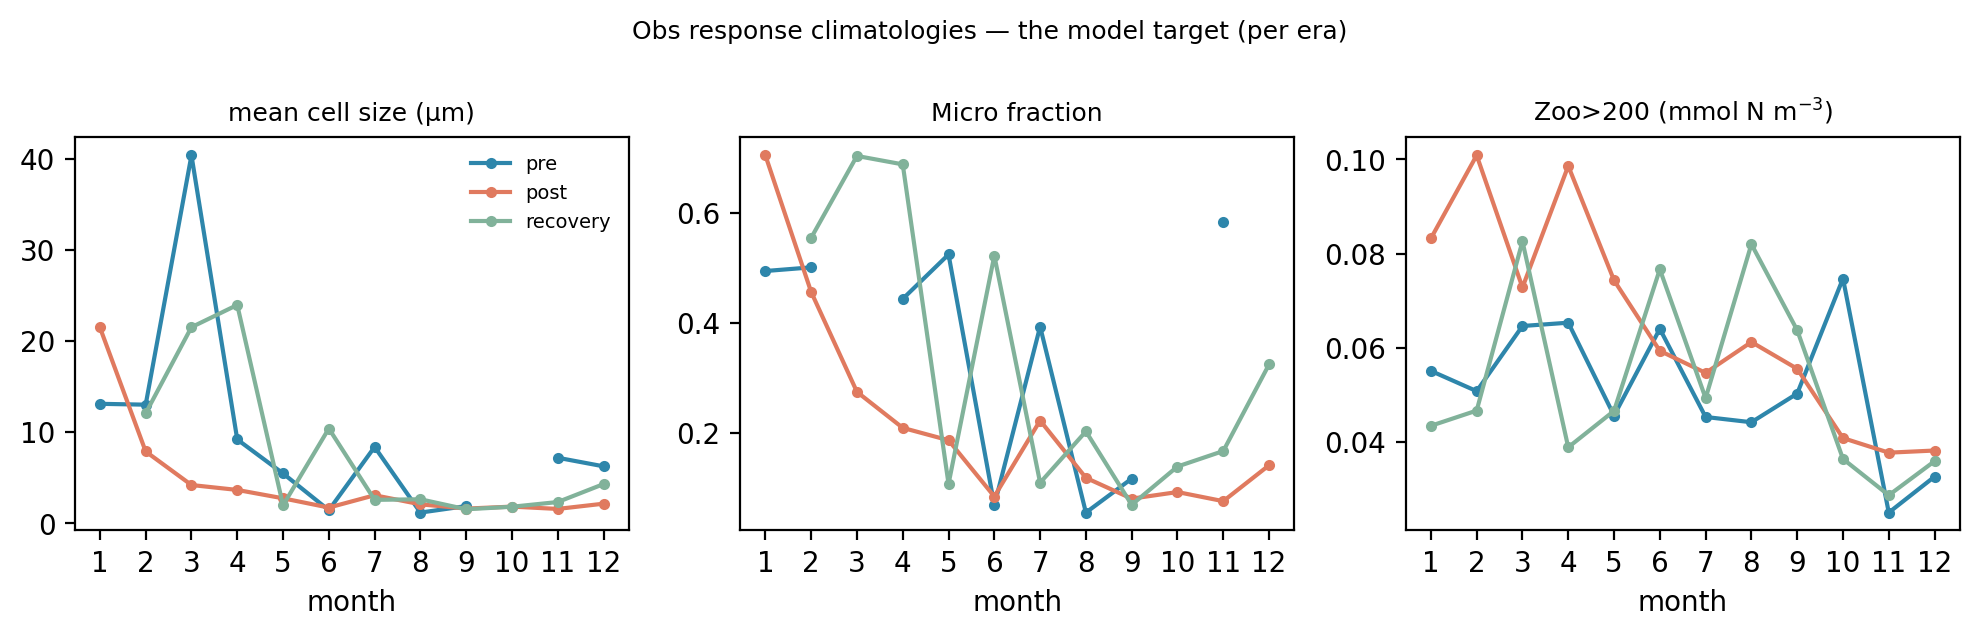

In [5]:
# === Obs RESPONSE climatologies (the model target): mcs, P/N/M, large-Z ===
SIZE, Z200, binc = 'size_centroid', 'zoo_gt200_mmolN', ['pico_mmolN','nano_mmolN','micro_mmolN']

def clim_resp(dd):
    out, cs = {}, dd.dropna(subset=[SIZE]).groupby('mo')[SIZE]
    out['mcs_um']     = (10**cs.mean()).reindex(range(1,13))
    out['mcs_med_um'] = (10**cs.median()).reindex(range(1,13))
    out['n_size']     = cs.size().reindex(range(1,13)).astype('Int64')
    fb = dd.dropna(subset=binc).copy(); t = fb[binc].sum(axis=1)
    for b, c in zip(['Pico','Nano','Micro'], binc):
        fb[b] = fb[c]/t
        out[b] = fb.groupby('mo')[b].mean().reindex(range(1,13))
    out['Zoo>200'] = dd.dropna(subset=[Z200]).groupby('mo')[Z200].mean().reindex(range(1,13))
    return pd.DataFrame(out)

print('=== OBS RESPONSE CLIMATOLOGIES (what the model must hit) ===')
for gname, eras in GROUPS.items():
    R = clim_resp(df[df['era'].isin(eras)])
    print(f'\n--- {gname} ---'); print(R.round(3).to_string())
    print(f"  annual: mcs mean={R['mcs_um'].mean():.2f}um med={R['mcs_med_um'].mean():.2f}um | "
          f"P/N/M={R['Pico'].mean():.2f}/{R['Nano'].mean():.2f}/{R['Micro'].mean():.2f} | "
          f"Zoo>200={R['Zoo>200'].mean():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2)); mons = list(range(1,13))
for ax,(m,lab) in zip(axes, [('mcs_um','mean cell size (µm)'),
                             ('Micro','Micro fraction'),
                             ('Zoo>200','Zoo>200 (mmol N m$^{-3}$)')]):
    for g in ['pre','post','recovery']:
        ax.plot(mons, clim_resp(df[df['era'].isin(GROUPS[g])])[m],
                '-o', ms=3, color=ERA_COL[g], label=g)
    ax.set_xlabel('month'); ax.set_title(lab, fontsize=9); ax.set_xticks(mons)
axes[0].legend(frameon=False, fontsize=7)
fig.suptitle('Obs response climatologies — the model target (per era)', fontsize=9)
fig.tight_layout(); plt.show()

=== model-ready 12-month forcing arrays ===

--- pre ---
     F_N   d_e      T
1   4.88  29.3  24.16
2   5.70  29.3  22.91
3   6.09  29.2  22.27
4   2.77  38.1  23.48
5   5.47  37.2  23.47
6   2.02  48.3  24.12
7   2.53  39.9  23.30
8   1.89  51.8  24.50
9   1.27  49.4  25.85
10  1.54  53.6  25.84
11  1.36  53.1  26.05
12  2.24  45.0  25.43

--- post ---
     F_N   d_e      T
1   3.14  36.3  24.52
2   4.80  33.5  23.29
3   3.31  40.6  23.08
4   2.93  44.5  22.86
5   1.87  49.9  24.46
6   1.60  52.9  25.16
7   2.20  50.5  24.30
8   1.74  49.8  24.95
9   1.36  54.3  26.48
10  1.54  56.4  26.17
11  0.75  48.2  27.24
12  1.28  54.1  25.78

--- recovery ---
     F_N   d_e      T
1   3.48  36.8  22.55
2   5.75  32.8  22.18
3   0.78  40.1  23.21
4   1.89  32.1  22.14
5   2.63  34.4  23.94
6   4.36  53.7  23.60
7   2.54  48.2  23.54
8   2.62  42.8  23.06
9   2.35  43.4  25.54
10  1.53  55.0  25.41
11  1.83  50.8  25.26
12  1.87  44.9  25.24

--- pre+recovery ---
     F_N   d_e      T
1   4.71 

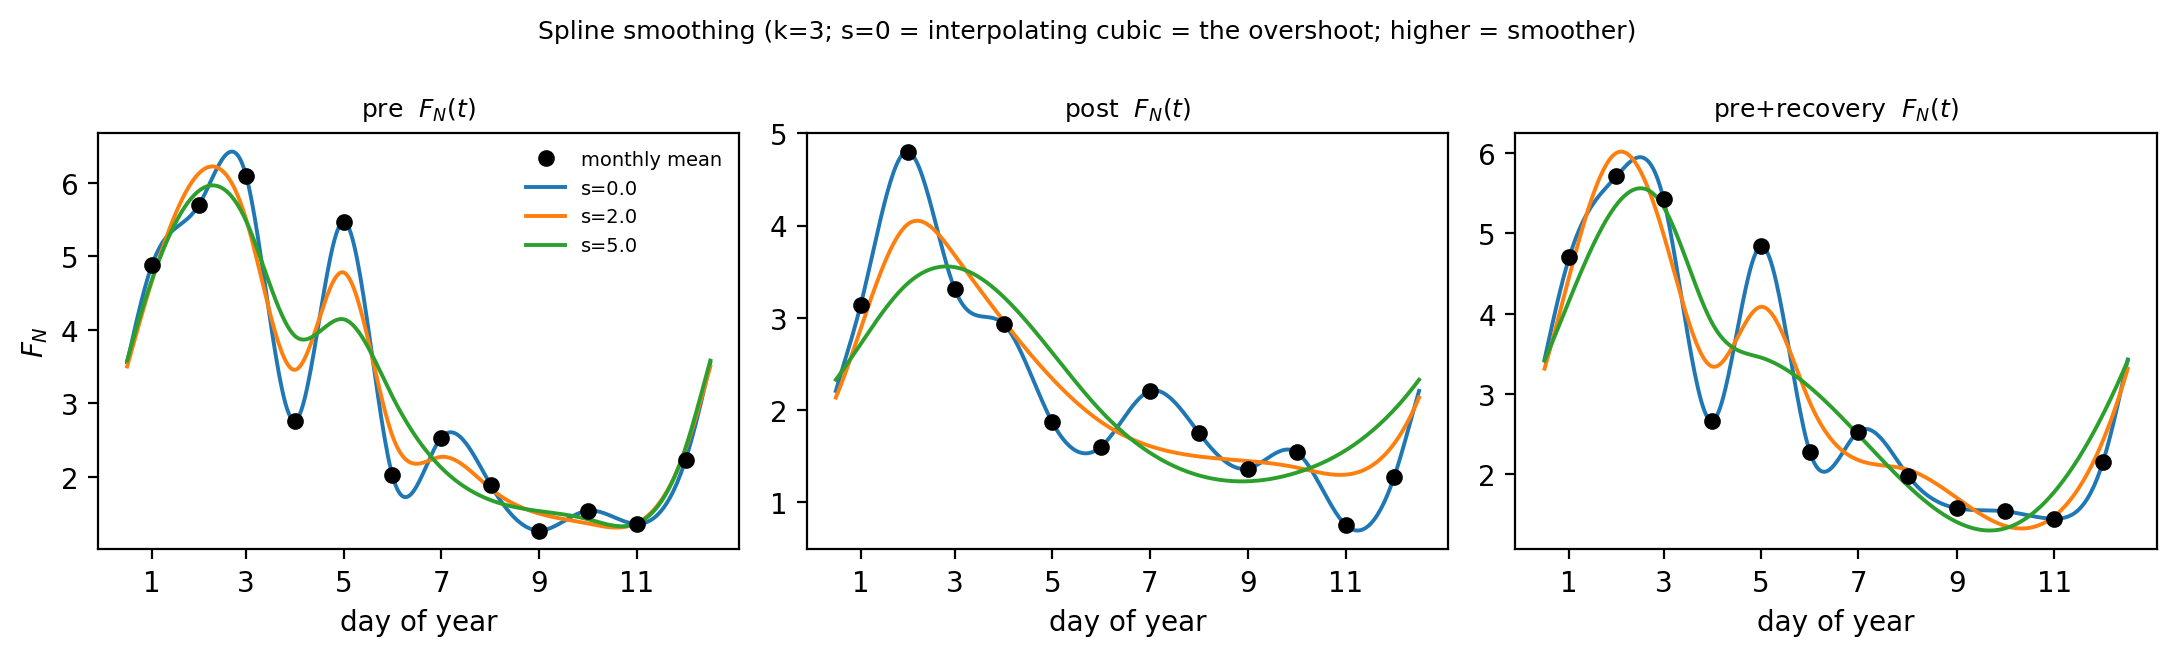


Pick s from the plot (it feeds make_seasonal_input_vars spline_s); same s applies to d_e/T.


In [6]:
# === Step 1: per-era seasonal forcing (F_N, d_e, T) + spline smoothing check ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import scipy.interpolate as intrp
from cariaco_obs import DEFAULT_CSV_PATH

FN, DE, TC = 'FN_mmolN_m2_d', 'depth_cutoff', 'Temp_C'
GROUPS = {'pre':['pre'],'post':['post'],'recovery':['recovery'],
          'pre+recovery':['pre','recovery'],'post+recovery':['post','recovery']}
ERA_COL = {'pre':'#2E86AB','post':'#E07A5F','pre+recovery':'#3F51B5'}

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = np.where(df['date'].dt.year < 2005,'pre',
            np.where(df['date'].dt.year < 2014,'post','recovery'))
df['mo'] = df['date'].dt.month

_DPM = np.array([31,28,31,30,31,30,31,31,30,31,30,31], float)
_MID = np.cumsum(_DPM) - _DPM/2.0; PERIOD = 365.0
def periodic_spline(monthly, k=3, s=0.0, period=PERIOD):     # verbatim comps pattern
    m = np.asarray(monthly, float)
    x = np.concatenate([[0.0], _MID, [period]])
    wrap = (m[0]+m[-1])/2.0; y = np.concatenate([[wrap], m, [wrap]])
    tck = intrp.splrep(x, y, per=True, k=k, s=s)
    return lambda t: np.maximum(intrp.splev(np.mod(t, period), tck, der=0), 0.0)

def monthly_means(eras, col):
    d = df[df['era'].isin(eras)].dropna(subset=[col])
    s = d.groupby('mo')[col].mean().reindex(range(1,13))
    if s.isna().any(): print(f"  [fill] {col} {eras}: months {list(s.index[s.isna()])} interpolated")
    return s.interpolate(limit_direction='both')

FORCING = {}
print('=== model-ready 12-month forcing arrays ===')
for g, eras in GROUPS.items():
    FORCING[g] = {'fn':monthly_means(eras,FN).values,'de':monthly_means(eras,DE).values,
                  't':monthly_means(eras,TC).values}
    print(f"\n--- {g} ---")
    print(pd.DataFrame({'F_N':FORCING[g]['fn'].round(2),'d_e':FORCING[g]['de'].round(1),
                        'T':FORCING[g]['t'].round(2)}, index=range(1,13)).to_string())

# smoothing diagnostic on F_N (the peaky one); d_e/T inherit the same s
tt = np.linspace(0, PERIOD, 366)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.3))
for ax, g in zip(axes, ['pre','post','pre+recovery']):
    ax.plot(_MID, FORCING[g]['fn'], 'ko', ms=5, zorder=5, label='monthly mean')
    for s in [0.0, 2.0, 5.0]:
        ax.plot(tt, periodic_spline(FORCING[g]['fn'], s=s)(tt), lw=1.4, label=f's={s}')
    ax.set_title(f'{g}  $F_N(t)$', fontsize=9); ax.set_xlabel('day of year')
    ax.set_xticks(_MID[::2]); ax.set_xticklabels(range(1,13,2))
axes[0].set_ylabel('$F_N$'); axes[0].legend(fontsize=7, frameon=False)
fig.suptitle('Spline smoothing (k=3; s=0 = interpolating cubic = the overshoot; higher = smoother)', fontsize=9)
fig.tight_layout(); plt.show()
print("\nPick s from the plot (it feeds make_seasonal_input_vars spline_s); same s applies to d_e/T.")